In [558]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Load and preprocess data
iris = load_iris()
X = iris.data
y = iris.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the input features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

In [ ]:
class SimpleIrisNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 12)       # Hidden layer 
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(12, 3)    7   # Output layer (3 classes)

    def forward(self, x):
        x = self.relu(self.fc1(x))       # Non-linear hidden layer
        return self.fc2(x)               # Raw logits (CrossEntropyLoss handles softmax)
model = SimpleIrisNet()

In [560]:
# 3. Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. Training loop with test evaluation
epochs = 80
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    # Training
    model.train()
    train_output = model(X_train)
    train_loss = criterion(train_output, y_train)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Accuracy (train)
    _, train_pred = torch.max(train_output, 1)
    train_correct = (train_pred == y_train).float().sum().item()
    train_acc = train_correct / len(y_train)
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        test_output = model(X_test)
        test_loss = criterion(test_output, y_test)
        _, test_pred = torch.max(test_output, 1)
        test_correct = (test_pred == y_test).float().sum().item()
        test_acc = test_correct / len(y_test)

    # Log metrics
    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # Print progress every 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}, "
              f"Train Acc: {train_acc:.2%}, Test Acc: {test_acc:.2%}")


Epoch [20/80] Train Loss: 0.5162, Test Loss: 0.4248, Train Acc: 80.00%, Test Acc: 90.00%
Epoch [40/80] Train Loss: 0.3051, Test Loss: 0.2355, Train Acc: 90.00%, Test Acc: 93.33%
Epoch [60/80] Train Loss: 0.1778, Test Loss: 0.1329, Train Acc: 95.00%, Test Acc: 100.00%
Epoch [80/80] Train Loss: 0.1084, Test Loss: 0.0832, Train Acc: 95.83%, Test Acc: 96.67%



Final Test Accuracy: 96.67%


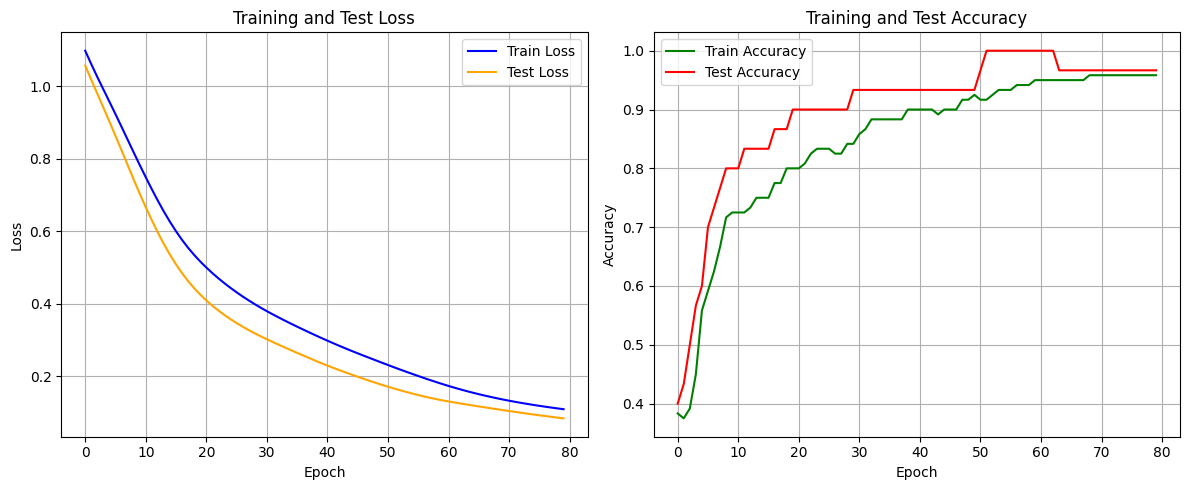

In [561]:


# Final test accuracy
print(f"\nFinal Test Accuracy: {test_accuracies[-1]*100:.2f}%")

# 5. Plotting loss and accuracy
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(test_losses, label='Test Loss', color='orange')
plt.title("Training and Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', color='green')
plt.plot(test_accuracies, label='Test Accuracy', color='red')
plt.title("Training and Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()